In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback, DataCollatorWithPadding
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', 20)

In [2]:
# 1. Создаём свой класс Dataset для PyTorch
class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Токенизируем текст
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            # padding=False,
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [3]:
import pandas as pd

df = pd.read_csv('../dataset/extended_by_deepseek_3.csv', sep=',')
df = df[df['тема'].notna()]
df = df[df['текст'].notna()]
df = df[['тема', 'текст']]

# темы, по которым пока не был получен ответ от deepseek:
df = df[df['тема'] != "вышка тура"]
df = df[df['тема'] != "плиткорез электрический"]
df = df[df['тема'] != "реноватор аккумуляторный"]
df = df[df['тема'] != "присоска"]
df = df[df['тема'] != "нивелир оптический"]
df = df[df['тема'] != "детектор проводки"]
df = df[df['тема'] != "дрель магнитная"]

# df = df[df['тема'] != "не вопрос клиента"]
df

,тема,текст
0,дрель-шуруповерт,"добрый вечер! подскажите, у вас можно взять в ..."
1,пылесос,Здравствуйте) сколько стоит аренда строительно...
2,плиткорез ручной,Доброе утро. Подскажите пожалуйста в какую цен...
3,фен,Доброе утро Есть строительный фен на аккумулят...
4,не вопрос клиента,Добрый день
...,...,...
1492,пароочиститель,"'Здравствуйте, есть ли в прокате устройство д..."
1493,пароочиститель,"'Привет, сколько стоит арендовать пароочистит..."
1494,пароочиститель,"'Добрый день, нужен пароочиститель для уборки..."
1495,пароочиститель,"'Здравствуйте, подскажите, можно ли взять пар..."


In [4]:
def clear_text(text: str) -> str:
    # функция очистки текстов от паразитных слов, не относящихся к теме запроса
    
    trash_values = [
        'добрый вечер', 
        'добрый день', 
        'доброе утро',
        'добрый утро',
        'здравствуйте',
        'подскажите',
        'пожалуйста',
        'хотелось',
        'интересует',
        'нужен',
        'нужно',
        'хочу',
        'надо',
        'можно',
        'аренда',
        'аренду',
        'хочу',
        'хотел бы',
        'в наличии',
        'сколько стоит',
        ',',
        "'",
    ]
    text = text.lower()
    for value in trash_values:
        text = text.replace(value, '')
    return text

In [5]:
df['текст'] = df['текст'].map(clear_text)
df

,тема,текст
0,дрель-шуруповерт,! у вас взять в шурповерт?
1,пылесос,) строительного пылесоса на сутки?
2,плиткорез ручной,. в какую цену у вас следующие инструменты: ...
3,фен,есть строительный фен на аккумуляторной батареи?
4,не вопрос клиента,
...,...,...
1492,пароочиститель,есть ли в прокате устройство для чистки паро...
1493,пароочиститель,привет арендовать пароочиститель для чистки ...
1494,пароочиститель,пароочиститель для уборки после ремонта есть ?
1495,пароочиститель,ли взять пароочиститель на сутки?


In [6]:
df['номер темы'] = df['тема'].astype('category').cat.codes
df

,тема,текст,номер темы
0,дрель-шуруповерт,! у вас взять в шурповерт?,19
1,пылесос,) строительного пылесоса на сутки?,59
2,плиткорез ручной,. в какую цену у вас следующие инструменты: ...,51
3,фен,есть строительный фен на аккумуляторной батареи?,76
4,не вопрос клиента,,36
...,...,...,...
1492,пароочиститель,есть ли в прокате устройство для чистки паро...,42
1493,пароочиститель,привет арендовать пароочиститель для чистки ...,42
1494,пароочиститель,пароочиститель для уборки после ремонта есть ?,42
1495,пароочиститель,ли взять пароочиститель на сутки?,42


In [7]:
df_small = df[df['тема']=='бензорез']
df_small

,тема,текст,номер темы
34,бензорез,. бензорез у вас есть?,5
254,бензорез,у вас есть в бетонорез?,5
678,бензорез,бензорез под 400 диск хускварна. есть такой?,5
809,бензорез,. с большим диском по бетону на сутки по како...,5
881,бензорез,есть ли бензорез с 400 диском в на одни сутки?,5
1076,бензорез,бензорез для резки металла на завтра ?,5
1077,бензорез,\n есть ли у вас бензорез для демонтажа заб...,5
1078,бензорез,\nпривет взять бензорез на пару часов чтобы...,5
1079,бензорез,\n ли арендовать бензорез на выходные?,5
1080,бензорез,\n взять бензорез на сутки резать арматуру?,5


In [8]:
summary = df['тема'].value_counts()
print(summary)

тема
не вопрос клиента                126
перфоратор                        78
пылесос                           65
дрель-шуруповерт                  55
торцовочная пила                  45
                                ... 
сабельная пила аккумуляторная     11
домкрат подкатной                 11
миксер                            10
сварочный аппарат                 10
Отбойный молоток                  10
Name: count, Length: 82, dtype: int64


In [9]:
# Применяем маску: оставляем только те строки, где размер темы >= 5
mask = df.groupby('тема')['тема'].transform('size') >= 5
df = df[mask]
df['номер темы'] = df['тема'].astype('category').cat.codes
df

,тема,текст,номер темы
0,дрель-шуруповерт,! у вас взять в шурповерт?,19
1,пылесос,) строительного пылесоса на сутки?,59
2,плиткорез ручной,. в какую цену у вас следующие инструменты: ...,51
3,фен,есть строительный фен на аккумуляторной батареи?,76
4,не вопрос клиента,,36
...,...,...,...
1492,пароочиститель,есть ли в прокате устройство для чистки паро...,42
1493,пароочиститель,привет арендовать пароочиститель для чистки ...,42
1494,пароочиститель,пароочиститель для уборки после ремонта есть ?,42
1495,пароочиститель,ли взять пароочиститель на сутки?,42


In [10]:
summary = df['тема'].value_counts()
print(summary)

тема
не вопрос клиента                126
перфоратор                        78
пылесос                           65
дрель-шуруповерт                  55
торцовочная пила                  45
                                ... 
сабельная пила аккумуляторная     11
домкрат подкатной                 11
миксер                            10
сварочный аппарат                 10
Отбойный молоток                  10
Name: count, Length: 82, dtype: int64


In [11]:
labels_df = df[['номер темы', 'тема']]
labels_df = labels_df.drop_duplicates(subset=['номер темы'])
labels_df = labels_df.sort_values(by='номер темы')
labels_df

,номер темы,тема
906,0,Отбойный молоток
39,1,УШМ
41,2,УШМ аккумуляторная
361,3,бензобур
330,4,бензопила
...,...,...
105,77,фен аккумуляторный
155,78,фрезер
163,79,шлифовальная машина
636,80,шнек для бензобура


In [12]:
labels_df.to_csv('../dataset/labels.csv')

In [13]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(df, test_size=0.1, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 1346, Val: 75, Test: 75


In [14]:
train_texts = train['текст'].tolist()
train_labels = train['номер темы'].tolist()
val_texts = val['текст'].tolist()
val_labels = val['номер темы'].tolist()
test_texts = test['текст'].tolist()
test_labels = test['номер темы'].tolist()

## learning rate 2e-5

In [15]:
# 4. Настраиваем параметры обучения
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,          
    per_device_train_batch_size=4, # маленький батч для CPU
    per_device_eval_batch_size=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    dataloader_pin_memory=False,
    logging_steps=5,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    learning_rate=2e-5,              # скорость обучения
    weight_decay=0.01,               # Регуляризация для борьбы с переобучением
    warmup_ratio=0.1,                # Прогрев в 10% от всего обучения
    lr_scheduler_type='cosine',      # затухание скорости
    optim='adamw_torch',             # оптимизатор
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [16]:
# 5. Функция для подсчёта метрик
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

In [17]:
training_results = {}

## Модель DeepPavlov/rubert-base-cased

In [18]:
# 2. Загружаем модель и токенизатор
import os
with open('hf_token.txt', encoding='utf-8') as f:
    token = f.read()
os.environ["HF_TOKEN"] = token
model_name = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(labels_df))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

In [19]:
train_dataset = IntentDataset(train_texts, train_labels, tokenizer)
val_dataset = IntentDataset(val_texts, val_labels, tokenizer)
test_dataset = IntentDataset(test_texts, test_labels, tokenizer)

In [20]:
# 6. Запускаем обучение
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)]
)

print("🚀 Начинаем обучение...")
trainer.train()

🚀 Начинаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,4.182154,4.208525,0.080000,0.134762,0.080000,0.084062
2,2.979785,3.154749,0.413333,0.337916,0.413333,0.344913
3,2.439503,2.163129,0.653333,0.577778,0.653333,0.600289
4,1.081495,1.539387,0.760000,0.756667,0.760000,0.738595
5,1.153076,1.146513,0.800000,0.781111,0.800000,0.776754
6,0.429139,0.878928,0.813333,0.813333,0.813333,0.797643
7,0.469491,0.734600,0.840000,0.848889,0.840000,0.833926
8,0.255720,0.641098,0.880000,0.891111,0.880000,0.876148
9,0.270357,0.548482,0.893333,0.911111,0.893333,0.893926
10,0.056854,0.574429,0.893333,0.917778,0.893333,0.898370


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=6740, training_loss=0.7772895847134933, metrics={'train_runtime': 2543.1891, 'train_samples_per_second': 10.585, 'train_steps_per_second': 2.65, 'total_flos': 1772009301504000.0, 'train_loss': 0.7772895847134933, 'epoch': 20.0})

In [21]:
# 7. Сохраняем модель
dir_name = model_name.replace('/', '_') + 'params1'
model.save_pretrained(os.path.join('..', 'models', dir_name))
tokenizer.save_pretrained(os.path.join('..', 'models', dir_name))

print("✅ Модель сохранена")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Модель сохранена


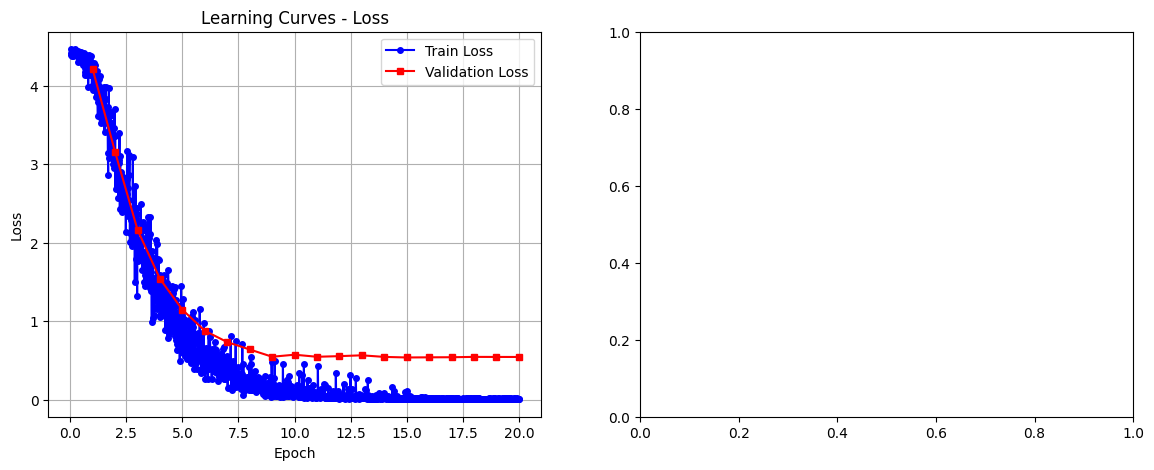

In [22]:
# Извлекаем историю обучения
log_history = trainer.state.log_history

# Разделяем train и eval логи
train_losses = []
eval_losses = []
eval_accuracies = []
eval_f1_scores = []
epochs_train = []
epochs_eval = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        # Training loss
        train_losses.append(log['loss'])
        epochs_train.append(log['epoch'])
    
    if 'eval_loss' in log and 'epoch' in log:
        # Evaluation metrics
        eval_losses.append(log['eval_loss'])
        eval_accuracies.append(log.get('eval_accuracy', None))
        eval_f1_scores.append(log.get('eval_f1_weighted', None))
        epochs_eval.append(log['epoch'])

# Создаем графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Loss
axes[0].plot(epochs_train, train_losses, 'b-', label='Train Loss', marker='o', markersize=4)
axes[0].plot(epochs_eval, eval_losses, 'r-', label='Validation Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Learning Curves - Loss')
axes[0].legend()
axes[0].grid(True)

In [23]:
print("🔮 Делаем предсказания на тестовой выборке...")
model = model.to('mps')
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

# f1_macro = f1_score(y_true, y_pred, average='macro')
# f1_weighted = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n📊 Общие метрики:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  precision: {precision:.4f}")
print(f"  recall: {recall:.4f}")
print(f"  f1: {f1:.4f}")

training_results[model_name] = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

🔮 Делаем предсказания на тестовой выборке...



📊 Общие метрики:
  Accuracy: 0.8667
  precision: 0.9444
  recall: 0.8667
  f1: 0.8803


In [24]:
training_results

{'DeepPavlov/rubert-base-cased': {'accuracy': 0.8666666666666667,
  'precision': 0.9444444444444444,
  'recall': 0.8666666666666667,
  'f1': 0.8803174603174603}}

## learning rate 1e-5

In [25]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,          
    per_device_train_batch_size=4, # маленький батч для CPU
    per_device_eval_batch_size=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    dataloader_pin_memory=False,
    logging_steps=5,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    learning_rate=1e-5,              # скорость обучения
    weight_decay=0.01,               # Регуляризация для борьбы с переобучением
    warmup_ratio=0.1,                # Прогрев в 10% от всего обучения
    lr_scheduler_type='cosine',      # затухание скорости
    optim='adamw_torch',             # оптимизатор
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [26]:
# 6. Запускаем обучение
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)]
)

print("🚀 Начинаем обучение...")
trainer.train()

🚀 Начинаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.056403,0.538936,0.906667,0.937778,0.906667,0.911704
2,0.020254,0.579300,0.906667,0.937778,0.906667,0.911704
3,0.019708,0.521351,0.893333,0.917778,0.893333,0.898370
4,0.011489,0.542102,0.906667,0.931111,0.906667,0.911704
5,0.010821,0.551677,0.893333,0.924444,0.893333,0.902815
6,0.005638,0.568962,0.893333,0.924444,0.893333,0.902815
7,0.008523,0.614630,0.880000,0.924444,0.880000,0.893926
8,0.005222,0.623039,0.880000,0.924444,0.880000,0.893926
9,0.005631,0.645073,0.880000,0.924444,0.880000,0.893926
10,0.004163,0.640984,0.893333,0.924444,0.893333,0.902815


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3707, training_loss=0.019884063963888105, metrics={'train_runtime': 1343.1073, 'train_samples_per_second': 20.043, 'train_steps_per_second': 5.018, 'total_flos': 974605115827200.0, 'train_loss': 0.019884063963888105, 'epoch': 11.0})

In [27]:
print("🔮 Делаем предсказания на тестовой выборке...")
model = model.to('mps')
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

# f1_macro = f1_score(y_true, y_pred, average='macro')
# f1_weighted = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n📊 Общие метрики:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  precision: {precision:.4f}")
print(f"  recall: {recall:.4f}")
print(f"  f1: {f1:.4f}")

training_results[model_name] = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

🔮 Делаем предсказания на тестовой выборке...



📊 Общие метрики:
  Accuracy: 0.8667
  precision: 0.9289
  recall: 0.8667
  f1: 0.8750


## metric eval_f1

In [34]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,          
    per_device_train_batch_size=4, # маленький батч для CPU
    per_device_eval_batch_size=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    dataloader_pin_memory=False,
    logging_steps=5,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True, 
    learning_rate=5e-5,              # скорость обучения
    weight_decay=0.01,               # Регуляризация для борьбы с переобучением
    warmup_ratio=0.1,                # Прогрев в 10% от всего обучения
    lr_scheduler_type='cosine',      # затухание скорости
    optim='adamw_torch',             # оптимизатор
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [35]:
# 2. Загружаем модель и токенизатор
import os
with open('hf_token.txt', encoding='utf-8') as f:
    token = f.read()
os.environ["HF_TOKEN"] = token
model_name = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(labels_df))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

In [36]:
# 6. Запускаем обучение
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)]
)

print("🚀 Начинаем обучение...")
trainer.train()

🚀 Начинаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,3.624627,3.682898,0.240000,0.132424,0.240000,0.155561
2,2.159700,2.177409,0.573333,0.470794,0.573333,0.502299
3,1.616686,1.391223,0.693333,0.652063,0.693333,0.653333
4,0.426092,0.748573,0.800000,0.782222,0.800000,0.781926
5,0.434715,0.543392,0.866667,0.906667,0.866667,0.877037
6,0.118541,0.555267,0.840000,0.861111,0.840000,0.837037
7,0.183073,0.501762,0.906667,0.931111,0.906667,0.911704
8,0.103492,0.515699,0.893333,0.908889,0.893333,0.888593
9,0.200412,0.608857,0.880000,0.897778,0.880000,0.880593
10,0.005773,0.483121,0.893333,0.911111,0.893333,0.893926


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=6740, training_loss=0.5179066035761125, metrics={'train_runtime': 2199.2434, 'train_samples_per_second': 12.241, 'train_steps_per_second': 3.065, 'total_flos': 1772009301504000.0, 'train_loss': 0.5179066035761125, 'epoch': 20.0})

In [37]:
print("🔮 Делаем предсказания на тестовой выборке...")
model = model.to('mps')
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

# f1_macro = f1_score(y_true, y_pred, average='macro')
# f1_weighted = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n📊 Общие метрики:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  precision: {precision:.4f}")
print(f"  recall: {recall:.4f}")
print(f"  f1: {f1:.4f}")

training_results[model_name] = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

🔮 Делаем предсказания на тестовой выборке...



📊 Общие метрики:
  Accuracy: 0.8667
  precision: 0.9378
  recall: 0.8667
  f1: 0.8768
